<a href="https://colab.research.google.com/github/niva1303-droid/Python-for-DA_Data-Visualization/blob/main/Python_for_DA_Data_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

**1) Loading the Taxis Dataset using the following code:**

In [2]:
import seaborn as sns
# Load the 'taxis' dataset
df = sns.load_dataset("taxis")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[ns]
 1   dropoff          6433 non-null   datetime64[ns]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   object        
 9   payment          6389 non-null   object        
 10  pickup_zone      6407 non-null   object        
 11  dropoff_zone     6388 non-null   object        
 12  pickup_borough   6407 non-null   object        
 13  dropoff_borough  6388 non-null   object        
dtypes: datetime64[ns](2), float64(5), int64(

In [4]:
df.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


In [5]:
print(df)

                  pickup             dropoff  passengers  distance  fare  \
0    2019-03-23 20:21:09 2019-03-23 20:27:24           1      1.60   7.0   
1    2019-03-04 16:11:55 2019-03-04 16:19:00           1      0.79   5.0   
2    2019-03-27 17:53:01 2019-03-27 18:00:25           1      1.37   7.5   
3    2019-03-10 01:23:59 2019-03-10 01:49:51           1      7.70  27.0   
4    2019-03-30 13:27:42 2019-03-30 13:37:14           3      2.16   9.0   
...                  ...                 ...         ...       ...   ...   
6428 2019-03-31 09:51:53 2019-03-31 09:55:27           1      0.75   4.5   
6429 2019-03-31 17:38:00 2019-03-31 18:34:23           1     18.74  58.0   
6430 2019-03-23 22:55:18 2019-03-23 23:14:25           1      4.14  16.0   
6431 2019-03-04 10:09:25 2019-03-04 10:14:29           1      1.12   6.0   
6432 2019-03-13 19:31:22 2019-03-13 19:48:02           1      3.85  15.0   

       tip  tolls  total   color      payment            pickup_zone  \
0     2.15    0

**2) Handling Missing Values**

In [8]:
df.isnull().sum()

,0
pickup,0
dropoff,0
passengers,0
distance,0
fare,0
tip,0
tolls,0
total,0
color,0
payment,44


In [9]:
missing_values = df.isnull().sum()

In [10]:
missing_values[missing_values>0]

,0
payment,44
pickup_zone,26
dropoff_zone,45
pickup_borough,26
dropoff_borough,45


In [11]:
missing_percentage = (missing_values /len(df))*100

In [12]:
missing_percentage[missing_percentage>0]

,0
payment,0.683973
pickup_zone,0.404166
dropoff_zone,0.699518
pickup_borough,0.404166
dropoff_borough,0.699518


In [14]:
df['payment'].value_counts()

,count
payment,
credit card,4577
cash,1812


In [15]:
df['payment'].mode()

,payment
0,credit card


In [16]:
df['payment'] = df['payment'].fillna(df['payment'].mode()[0])

In [18]:
df['payment'].isnull().sum()

np.int64(0)

In [19]:
df['pickup_borough'].value_counts()

,count
pickup_borough,
Manhattan,5268
Queens,657
Brooklyn,383
Bronx,99


In [23]:
df = df.dropna(
    subset=[
        "pickup_zone",
        "dropoff_zone",
        "pickup_borough",
        "dropoff_borough"
    ]
).copy()

In [21]:
df.isnull().sum()

,0
pickup,0
dropoff,0
passengers,0
distance,0
fare,0
tip,0
tolls,0
total,0
color,0
payment,0


# **3) Visualizations using Matplotlib/Pandas Plot:**

**a) Line Chart - Fare Over Time**

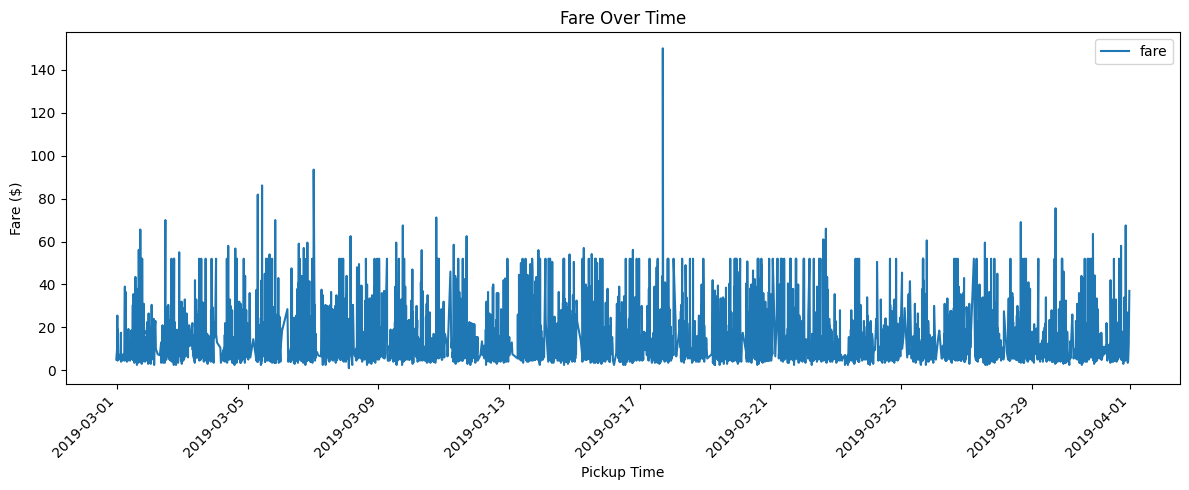

In [24]:
df['pickup'] = pd.to_datetime(df['pickup'])

df = df.sort_values('pickup')

df.plot(
    x='pickup',
    y='fare',
    kind='line',
    figsize=(12, 5)
)

plt.title('Fare Over Time')
plt.xlabel('Pickup Time')
plt.ylabel('Fare ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**b) Bar Chart — Total fare by pickup borough**

In [25]:
borough_fare = df.groupby('pickup_borough', observed=True)['fare'].sum()

borough_fare

,fare
pickup_borough,
Bronx,2078.91
Brooklyn,6227.48
Manhattan,58323.92
Queens,15541.06


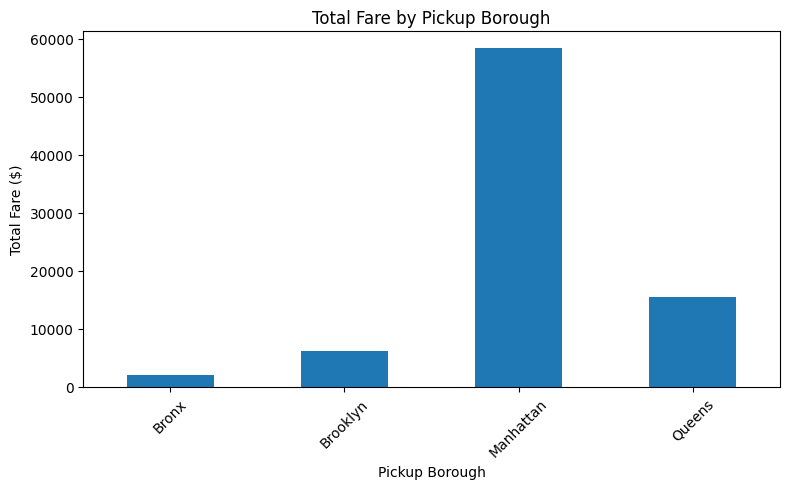

In [26]:
borough_fare.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Total Fare by Pickup Borough')
plt.xlabel('Pickup Borough')
plt.ylabel('Total Fare ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**c) Pie Chart — Trips by payment method**

In [27]:
payment_counts = df['payment'].value_counts()

payment_counts

,count
payment,
credit card,4588
cash,1795


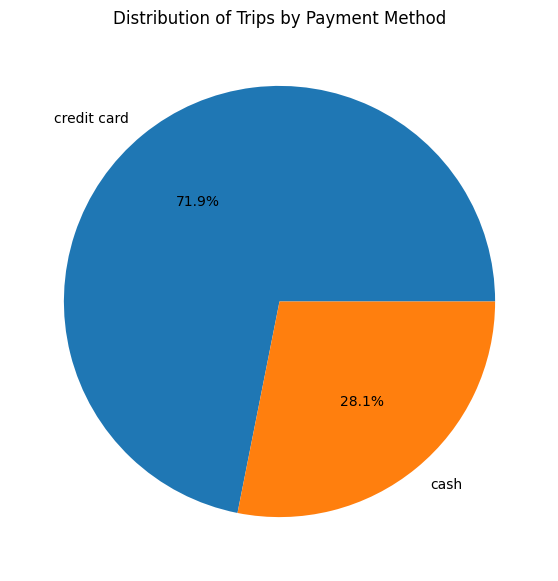

In [28]:
payment_counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(7, 7)
)

plt.title('Distribution of Trips by Payment Method')
plt.ylabel('')
plt.show()

**d) Histogram — Distribution of distance**

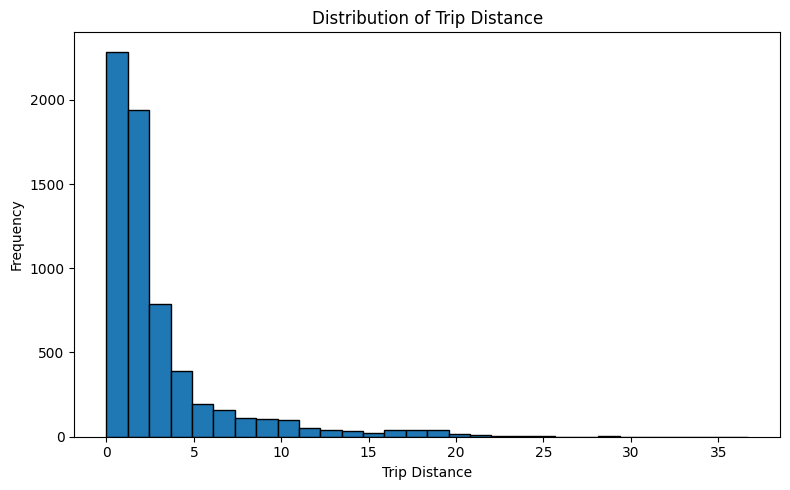

In [43]:
df['distance'].plot(
    kind='hist',
    bins=30,
    edgecolor='black',
    figsize=(8, 5)
)

plt.title('Distribution of Trip Distance')
plt.xlabel('Trip Distance')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

**e) Box Plot — Tip by pickup borough**

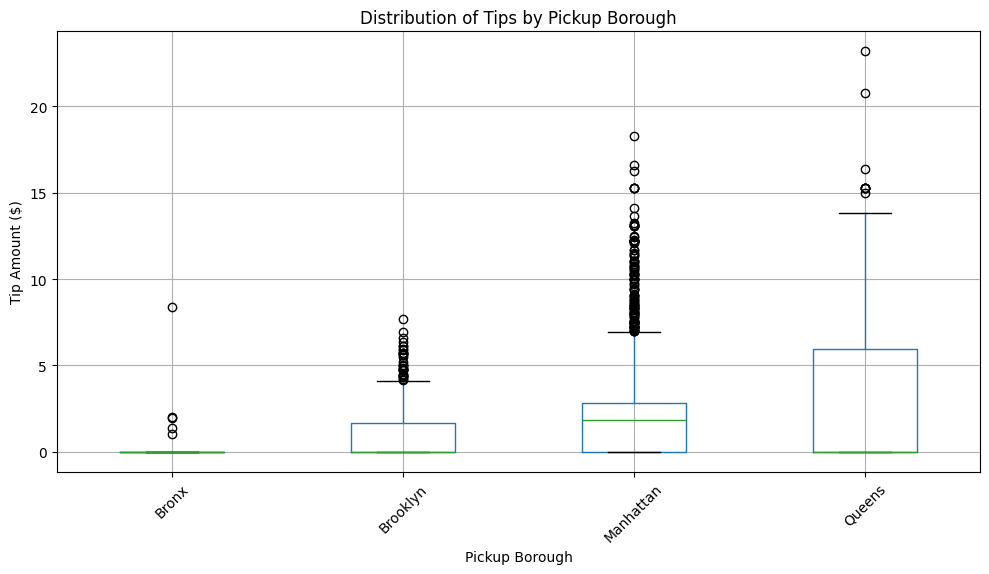

In [32]:
df.boxplot(
    column='tip',
    by='pickup_borough',
    figsize=(10, 6)
)

plt.title('Distribution of Tips by Pickup Borough')
plt.suptitle('')
plt.xlabel('Pickup Borough')
plt.ylabel('Tip Amount ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#**Visualizations using Seaborn:**

**a) 1. Count Plot — Number of trips by pickup borough**

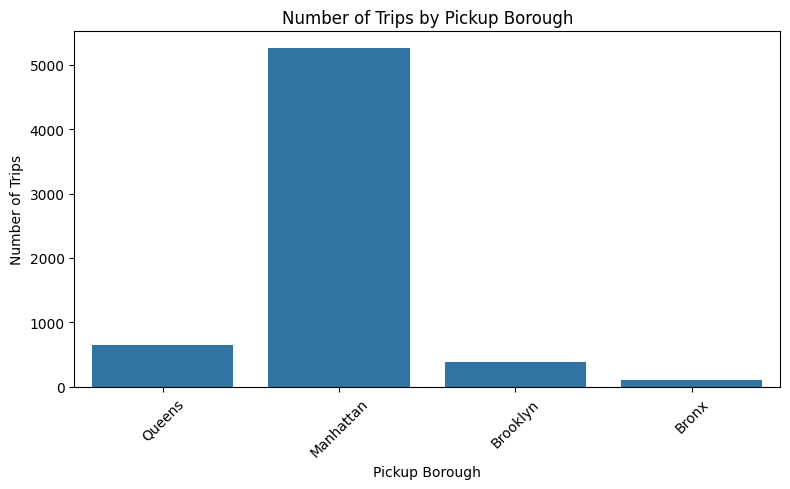

In [33]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='pickup_borough'
)

plt.title('Number of Trips by Pickup Borough')
plt.xlabel('Pickup Borough')
plt.ylabel('Number of Trips')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**b) Scatter Plot — Distance vs Fare**

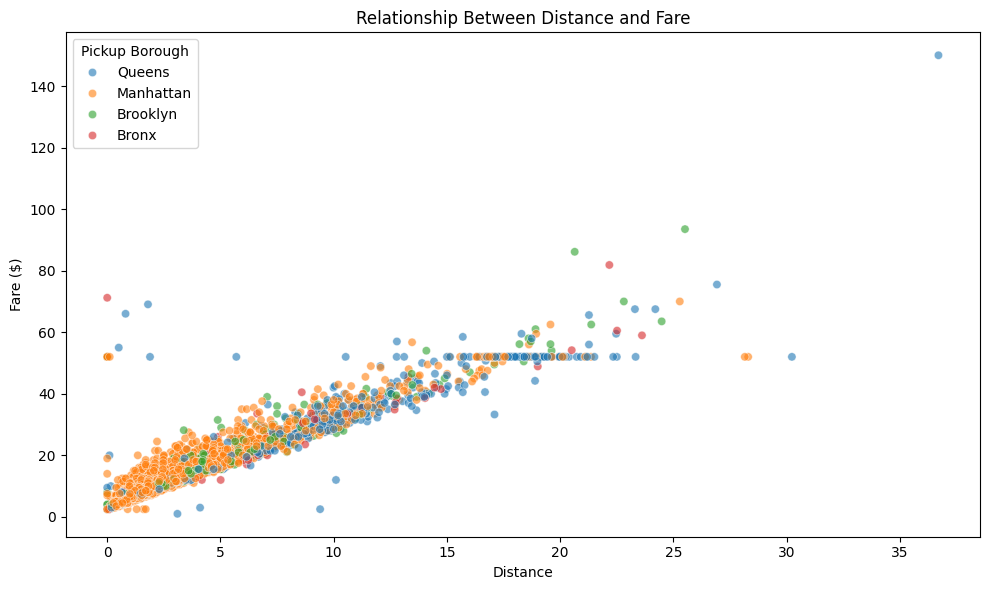

In [34]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='distance',
    y='fare',
    hue='pickup_borough',
    alpha=0.6
)

plt.title('Relationship Between Distance and Fare')
plt.xlabel('Distance')
plt.ylabel('Fare ($)')
plt.legend(title='Pickup Borough')
plt.tight_layout()
plt.show()

**c) Heatmap — Correlation between numerical variables**

In [36]:
correlation_matrix = df[
    ['distance', 'fare', 'tip', 'tolls', 'total']
].corr()

correlation_matrix

,distance,fare,tip,tolls,total
distance,1.000000,0.947021,0.475378,0.642899,0.928371
fare,0.947021,1.000000,0.485655,0.618184,0.972376
tip,0.475378,0.485655,1.000000,0.412787,0.649050
tolls,0.642899,0.618184,0.412787,1.000000,0.691506
total,0.928371,0.972376,0.649050,0.691506,1.000000


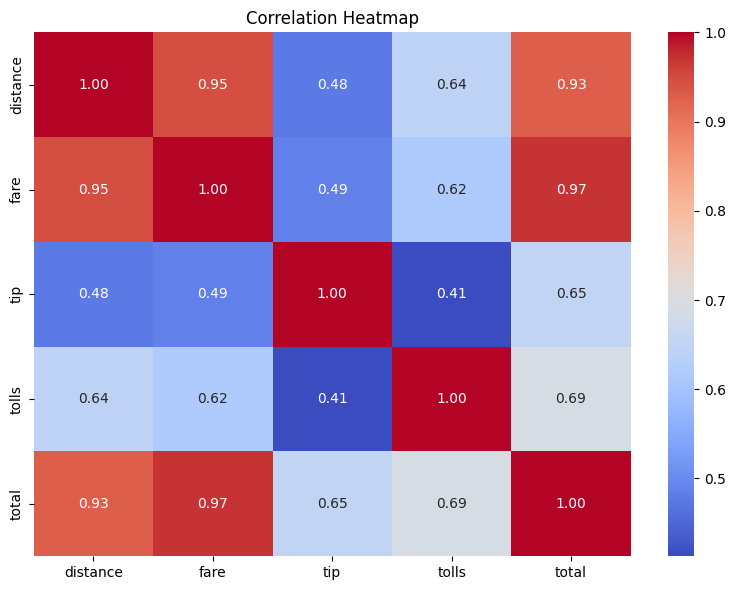

In [37]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

**d) Pair Plot — Distance, Fare, Tip and Total by Pickup Zone**

In [40]:
df['pickup_zone'].nunique()

df['pickup_zone'].value_counts()

,count
pickup_zone,
Midtown Center,229
Penn Station/Madison Sq West,210
Upper East Side South,210
Clinton East,208
Midtown East,197
...,...
Woodlawn/Wakefield,1
Hollis,1
Whitestone,1


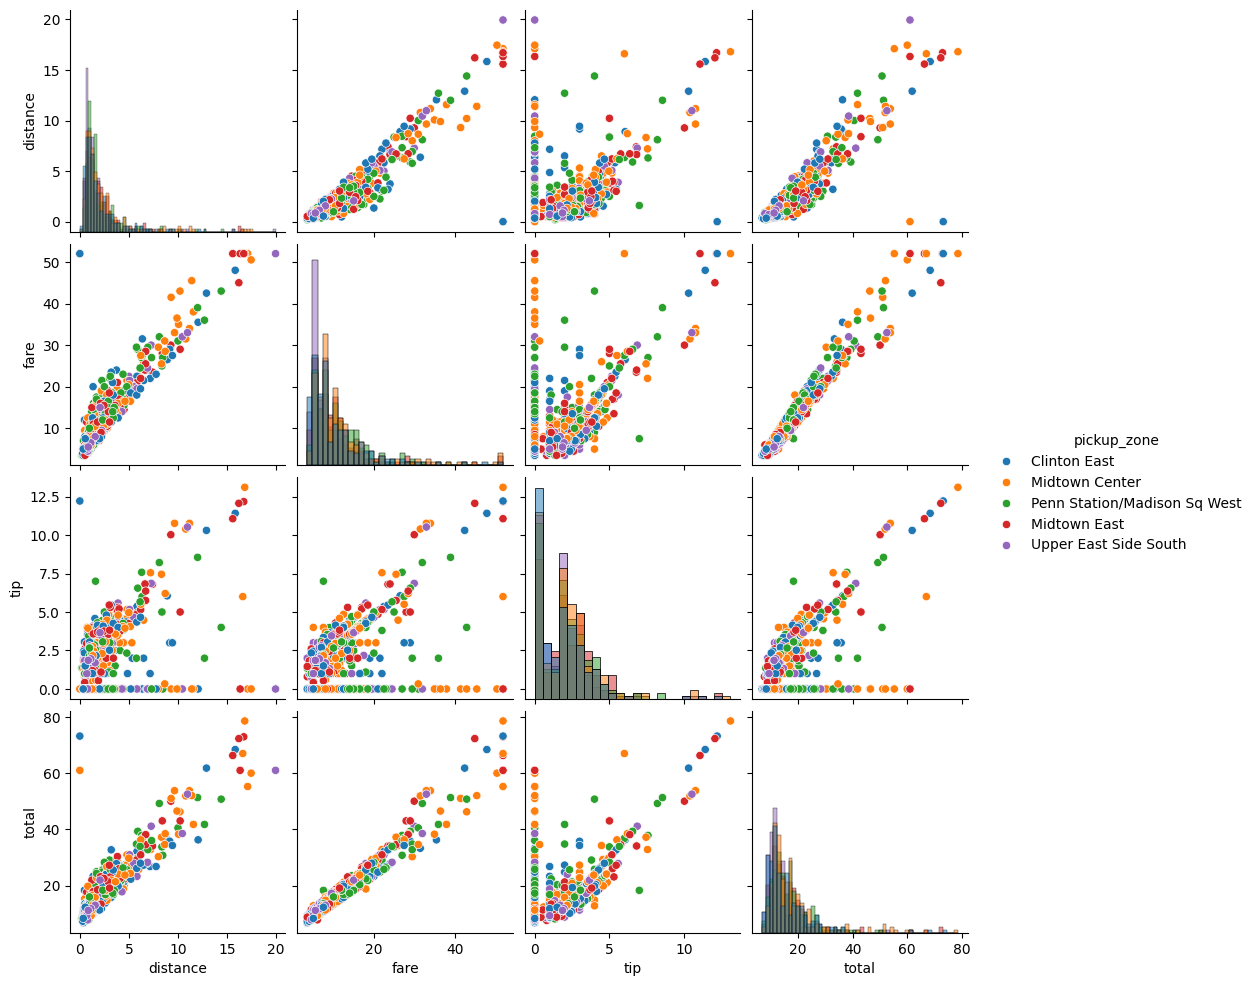

In [41]:
top_5_zones = df['pickup_zone'].value_counts().head(5).index

df_top5 = df[df['pickup_zone'].isin(top_5_zones)].copy()

sns.pairplot(
    data=df_top5,
    vars=['distance', 'fare', 'tip', 'total'],
    hue='pickup_zone',
    diag_kind='hist',
    height=2.5
)

plt.show()

**e) Violin Plot — Fare distribution by payment method**

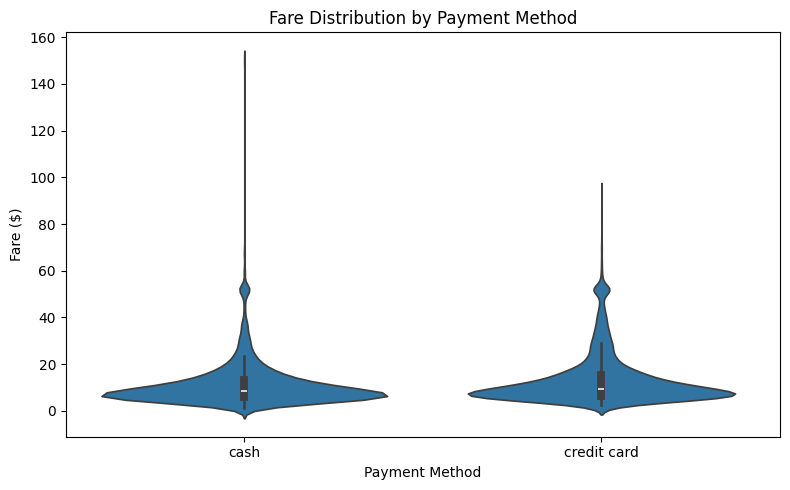

In [42]:
plt.figure(figsize=(8, 5))

sns.violinplot(
    data=df,
    x='payment',
    y='fare'
)

plt.title('Fare Distribution by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Fare ($)')
plt.tight_layout()
plt.show()

#**Key Findings**

**Fare Over Time:** The line chart showed variations in taxi fares across different pickup times. Individual trip fares fluctuate considerably, indicating differences in trip characteristics such as distance and destination.

**Fare by Pickup Borough:** The bar chart revealed differences in total fare generated across pickup boroughs. Boroughs with higher trip activity generally contributed more to the overall fare collected.

**Payment Method:** The pie chart showed that credit card was the dominant payment method, while cash represented a smaller proportion of trips. Before imputation, there were 4,577 credit-card trips compared with 1,812 cash trips.

**Trip Distance:** The histogram showed the distribution of taxi trip distances. Trips were concentrated within the lower-distance ranges, while relatively long-distance trips occurred less frequently.

**Tips by Borough:** The box plot demonstrated variation in tip amounts across pickup boroughs and also highlighted potential outliers where some passengers provided substantially higher tips.

**Trip Volume by Borough:** The count plot showed that taxi trip frequency differed considerably across pickup boroughs, indicating that some areas generated substantially more taxi activity than others.

**Distance and Fare Relationship: **The scatter plot indicated an overall positive relationship between trip distance and fare, with longer trips generally associated with higher fares. Some observations deviated from the general pattern.

**Correlation Analysis:** The heatmap was used to examine relationships among distance, fare, tip, tolls, and total. It showed that some trip-related numerical variables move together, particularly fare-related measures. The exact strength of these relationships can be identified from the correlation coefficients displayed in the heatmap.

**Pairwise Relationships:** The pair plot compared distance, fare, tip, and total for the five most frequent pickup zones. Limiting the analysis to the top five zones improved readability and reduced the computational complexity caused by the large number of unique pickup zones.

**Fare by Payment Method:** The violin plot compared fare distributions between payment methods and showed how the concentration and spread of fare amounts differed between cash and credit-card trips.
Conclusion

# **Conclusion**

The analysis demonstrates that taxi fares are influenced by trip characteristics, particularly distance, while trip activity and fare generation vary across pickup locations. Credit cards are the most commonly used payment method, and most taxi trips are concentrated within shorter-distance ranges. The visualizations also identify variation in fares and tips and highlight potential outliers.

Overall, the project demonstrates how data cleaning, aggregation, correlation analysis, and visualization can be combined to transform raw taxi-trip data into meaningful and interpretable insights.